<a href="https://colab.research.google.com/github/Raquelodaka/Previs-o-de-Churn-Banc-rio-e-Estrat-gia-de-Reten-o/blob/main/Previs%C3%A3o_de_Churn_Banc%C3%A1rio_e_Estrat%C3%A9gia_de_Reten%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Previsão de Churn Bancário e Estratégia de Retenção

1. Visão Geral do Negócio
No setor bancário e de serviços financeiros, a aquisição de novos clientes custa entre 5 a 25 vezes mais do que a retenção dos atuais. A perda contínua de clientes (churn) reduz o volume de depósitos, compromete a rentabilidade de cartões de crédito e enfraquece a carteira de crédito da instituição.

Este projeto simula o cenário real de uma Fintech/Instituição Bancária, onde a equipe de CRM necessita de uma solução analítica proativa para identificar sinais de evasão antes que o cliente encerre a conta ou migre para a concorrência.

2. Sobre a Base de Dados
O conjunto de dados contém registros cadastrais, financeiros e de engajamento de 5.000 clientes, refletindo o perfil comportamental dos usuários nos últimos meses:

Atributos Cadastrais: Idade, Genero, Anos_Como_Cliente (Tenure).

Atributos Financeiros & Risco: Score_Credito, Saldo_Conta, Salario_Estimado, Num_Produtos, Possui_Cartao_Credito.

Indicadores de Engajamento: Membro_Ativo (uso recente do internet banking) e Queda_Uso_App_Pct (variação percentual de uso do aplicativo nos últimos 60 dias).

Variável Alvo (Churn): Indicador binário que mapeia o cancelamento ou inatividade prolongada da conta (1 para Churn, 0 para Retido).

3. Objetivos do Modelo e Valor Esperado
Predição de Risco: Construir um algoritmo preditivo (XGBoost) para identificar com precisão a probabilidade individual de cancelamento nos próximos 30 a 90 dias, priorizando a métrica de Recall para capturar o maior número possível de evasões reais.

Avaliação de Impacto Financeiro (CLV): Estimar o Valor de Vida do Cliente (Customer Lifetime Value) para correlacionar o risco de saída ao valor patrimonial que o cliente representa para o banco.

Segmentação Comportamental (Clustering): Agrupar os clientes de alto risco via K-Means com base no seu padrão de uso e saldo, direcionando campanhas de retenção personalizadas para otimizar o retorno sobre o investimento (ROI) do time de Marketing/CRM.

In [ ]:
#baixar
#!pip install sweetviz -q
!pip install --upgrade xgboost pandas -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 85.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [ ]:
# Bibliotrcas utilizadas
import pandas as pd
import sweetviz as sv
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('/content/banco_customer_data.csv')
df

,ID_Cliente,Idade,Genero,Score_Credito,Anos_Como_Cliente,Saldo_Conta,Salario_Estimado,Num_Produtos,Possui_Cartao_Credito,Membro_Ativo,Queda_Uso_App_Pct,Churn
0,FIN-00001,56,M,373,0,0.00,5066.94,1,0,0,12.0,1
1,FIN-00002,69,M,715,6,16472.81,5425.16,2,1,1,24.9,0
2,FIN-00003,46,M,634,1,9788.27,18117.42,2,1,1,26.2,0
3,FIN-00004,32,F,595,0,117.91,23142.86,4,0,1,24.8,0
4,FIN-00005,60,M,383,1,0.00,18827.76,4,1,0,30.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,FIN-04996,67,M,341,6,0.00,22484.71,1,1,1,36.4,0
4996,FIN-04997,39,M,644,4,0.00,10032.24,2,1,1,54.0,0
4997,FIN-04998,46,M,560,0,3255.45,13920.34,2,1,1,27.1,0
4998,FIN-04999,39,F,605,1,8439.45,20040.80,2,0,1,24.8,0


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated.



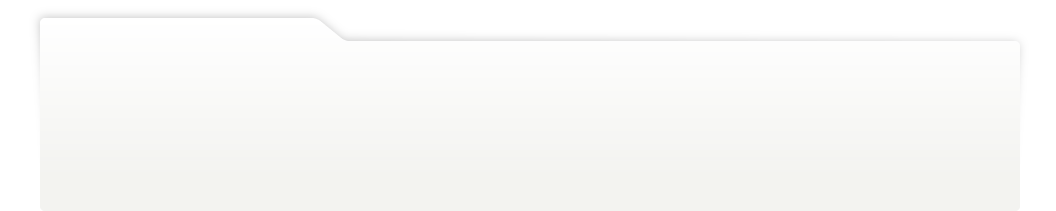
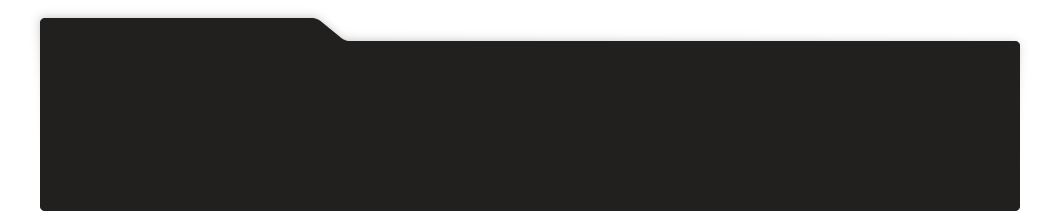
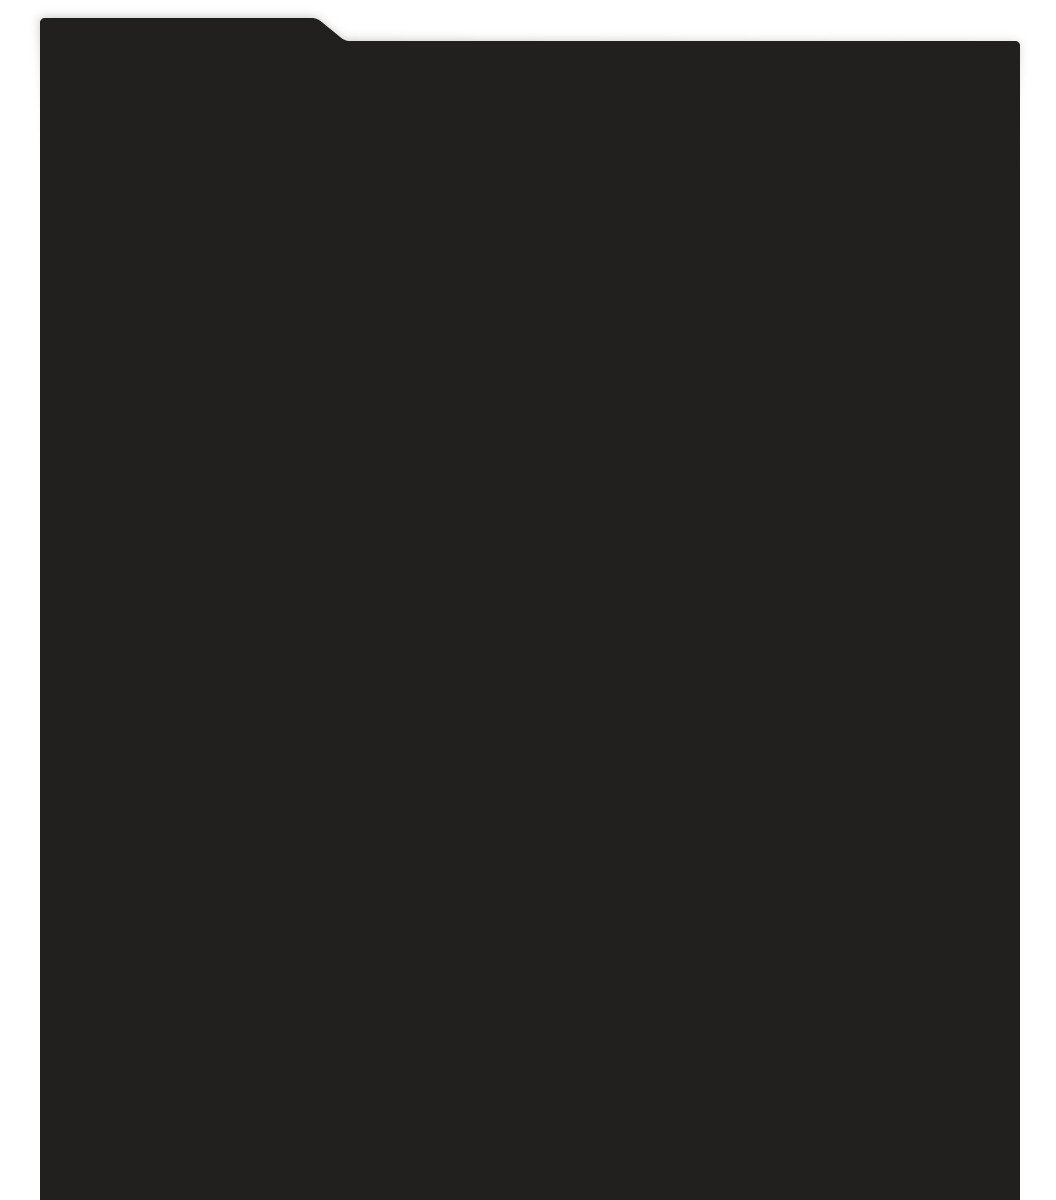
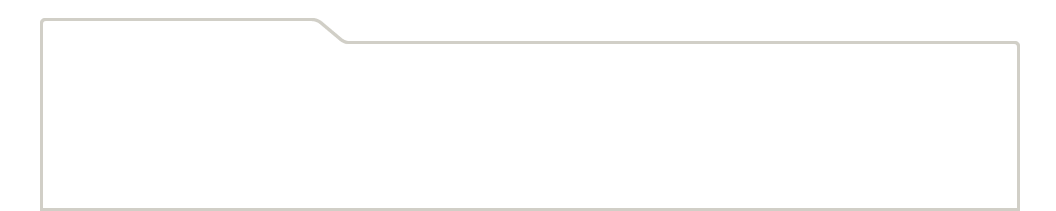
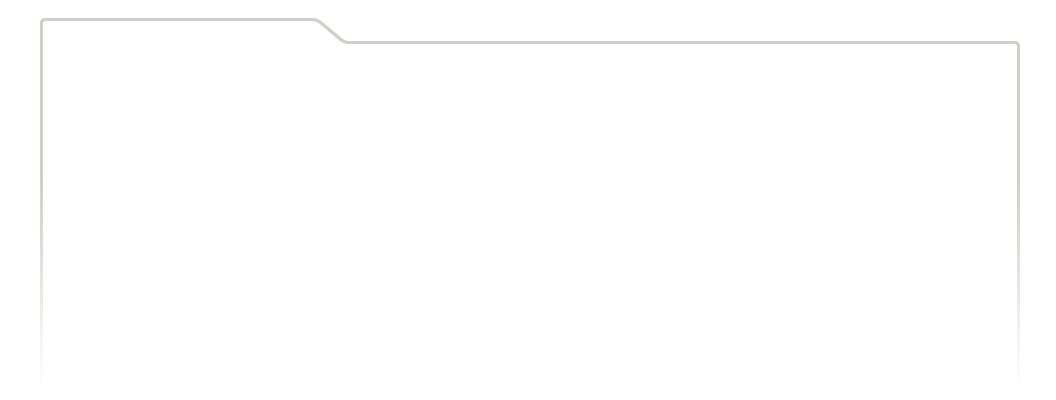
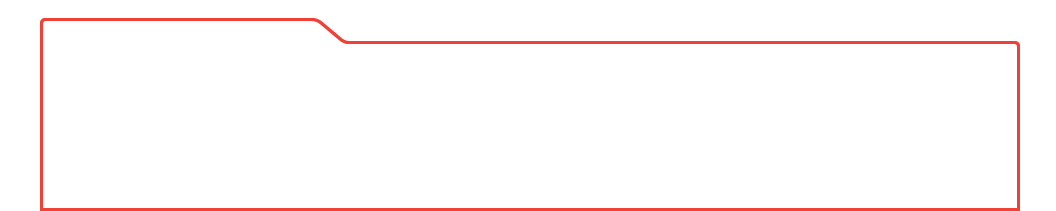
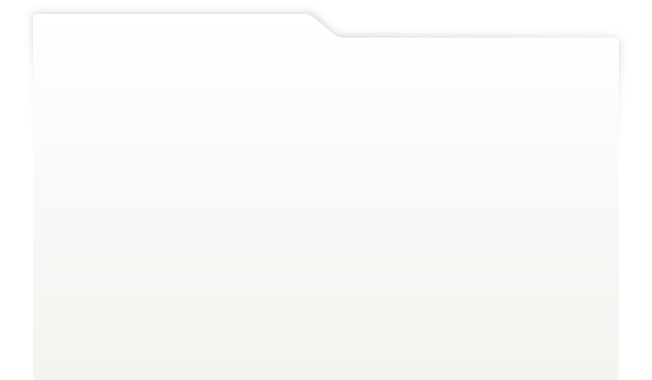
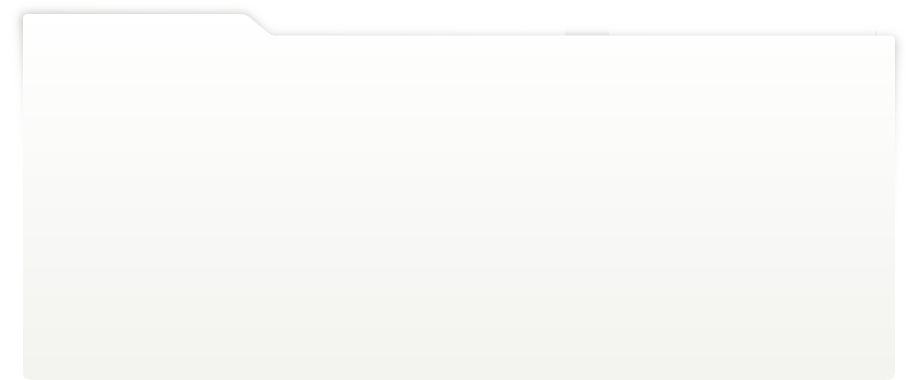
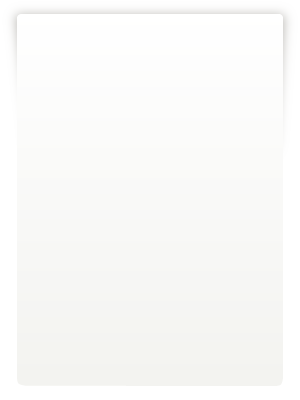
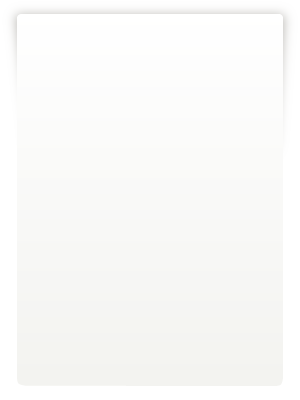
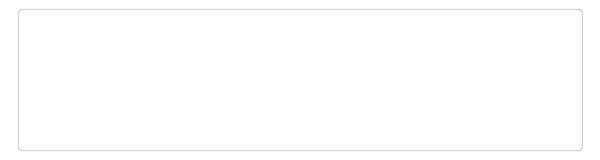
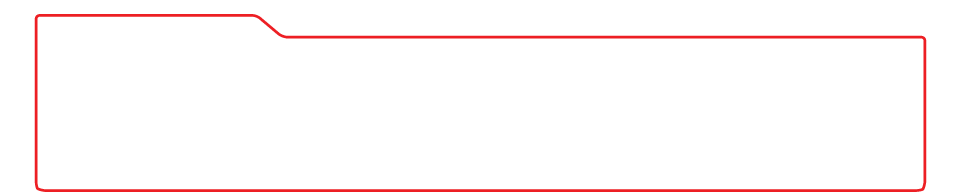
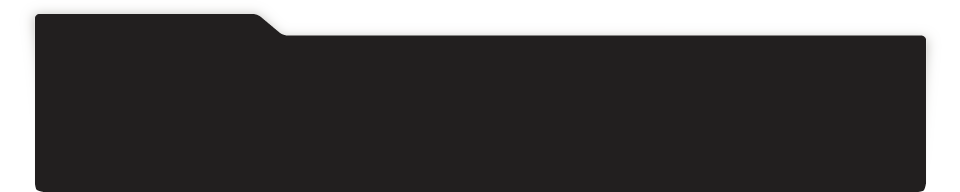
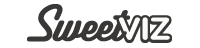
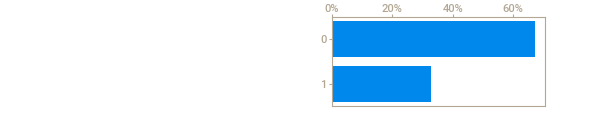
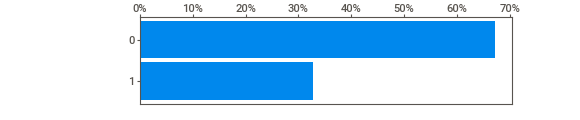
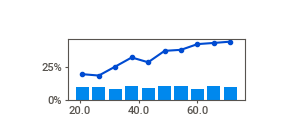
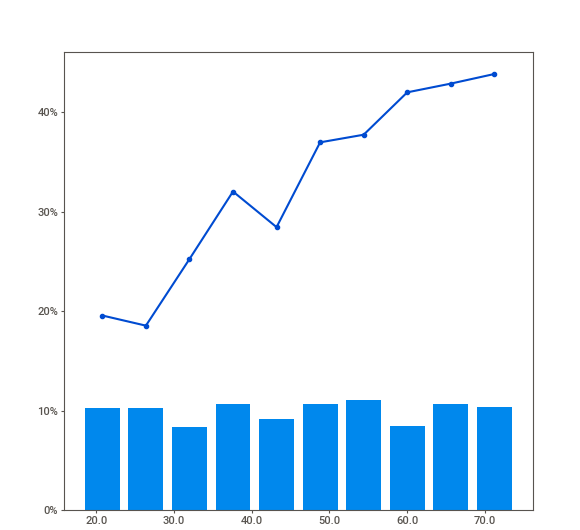
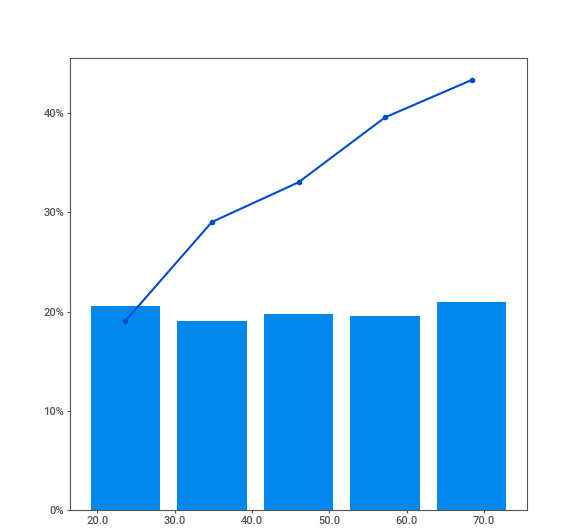
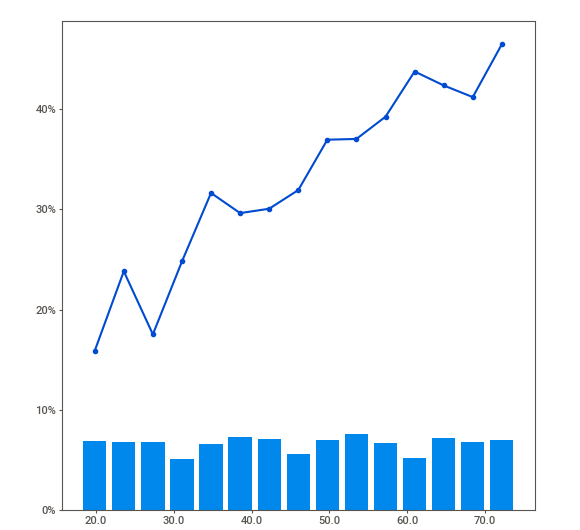
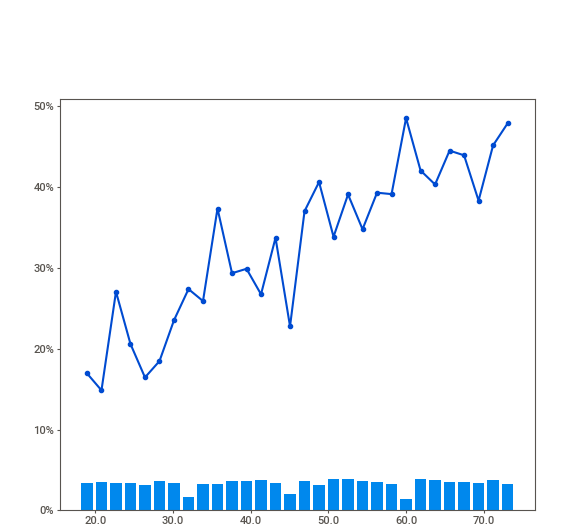
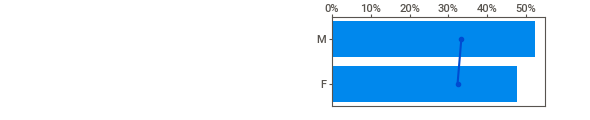
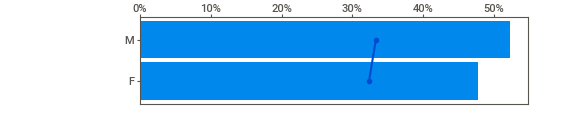
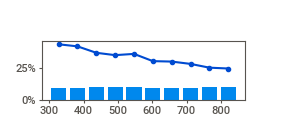
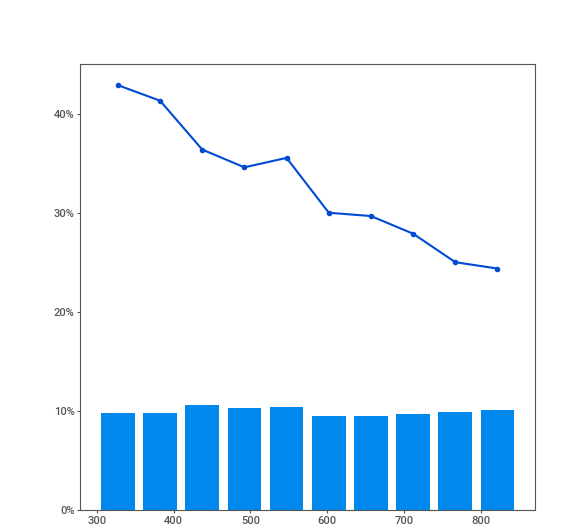
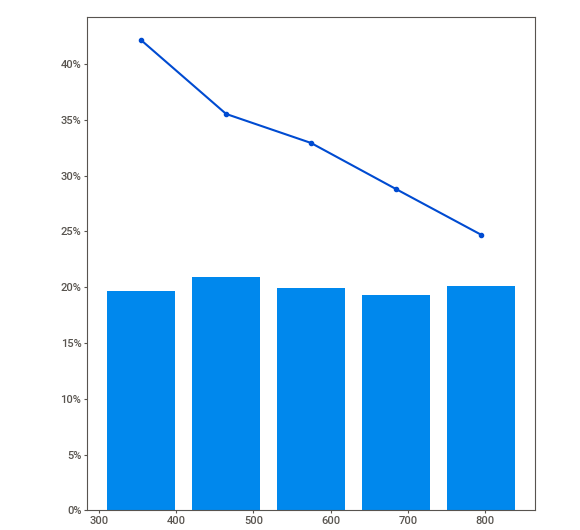
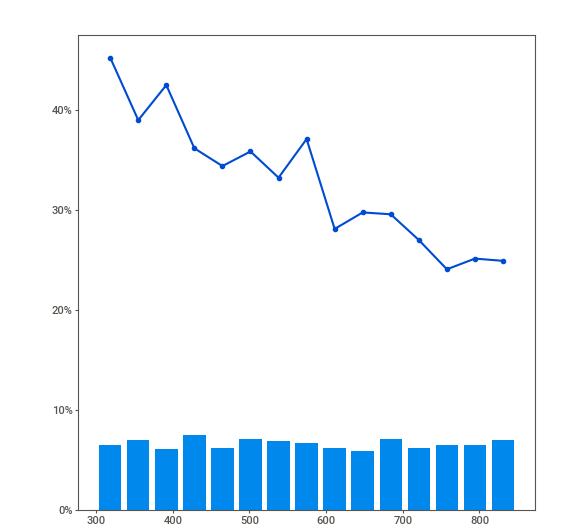
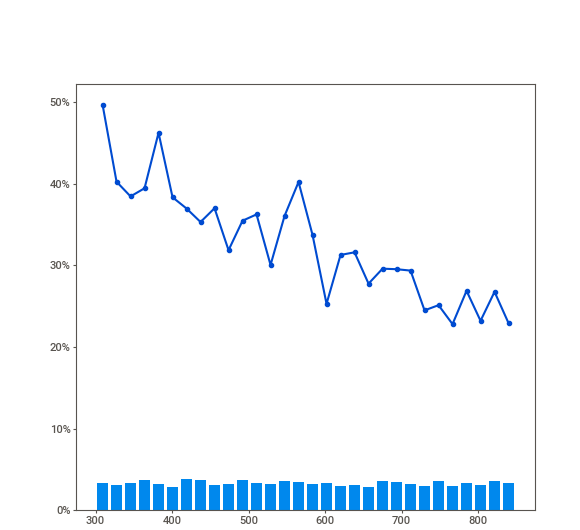
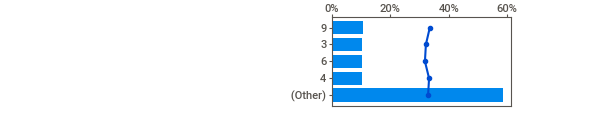
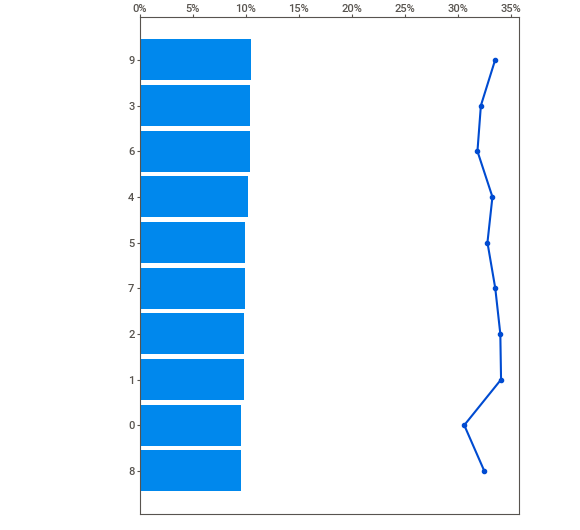
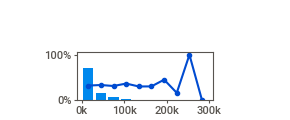
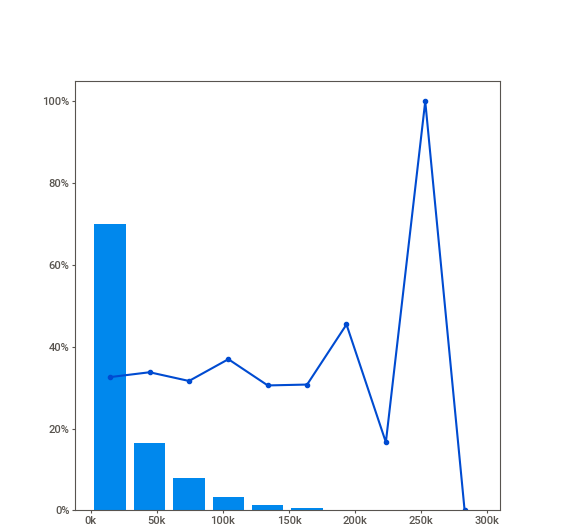
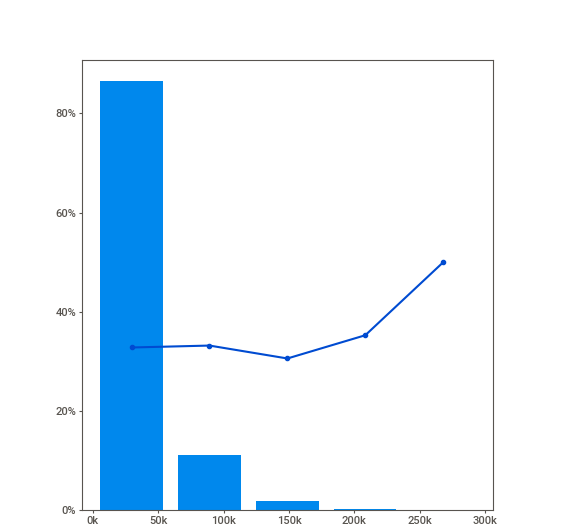
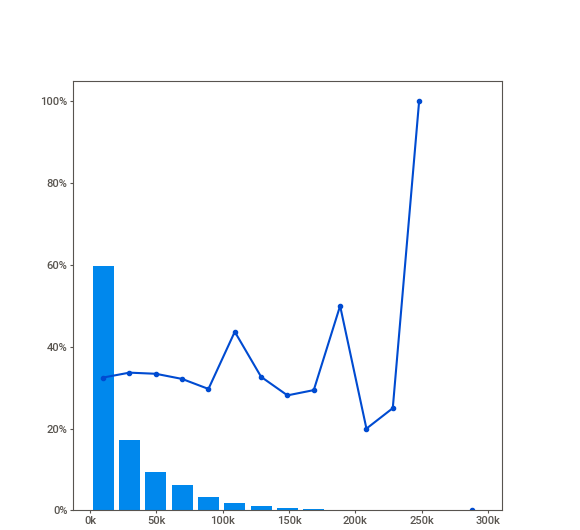
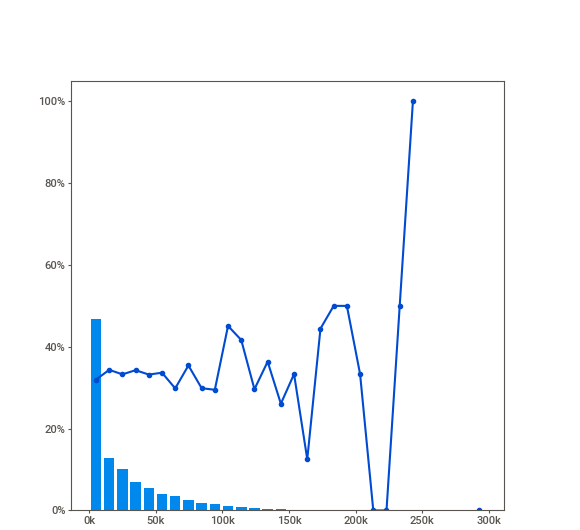
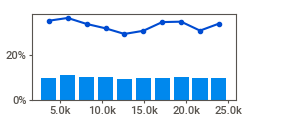
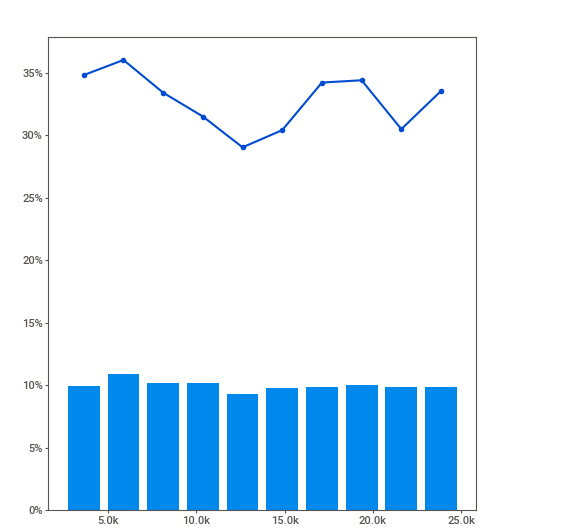
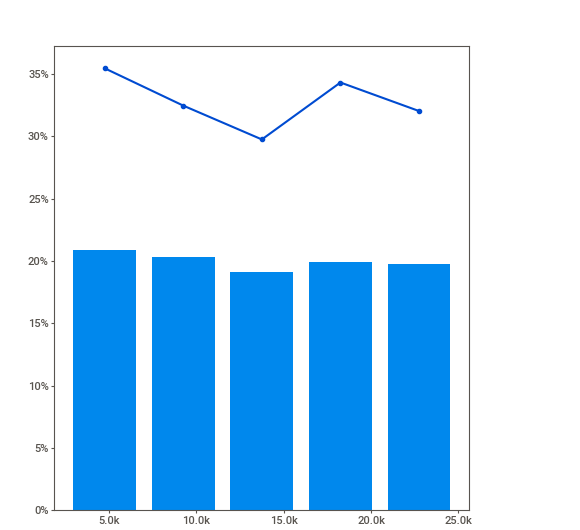
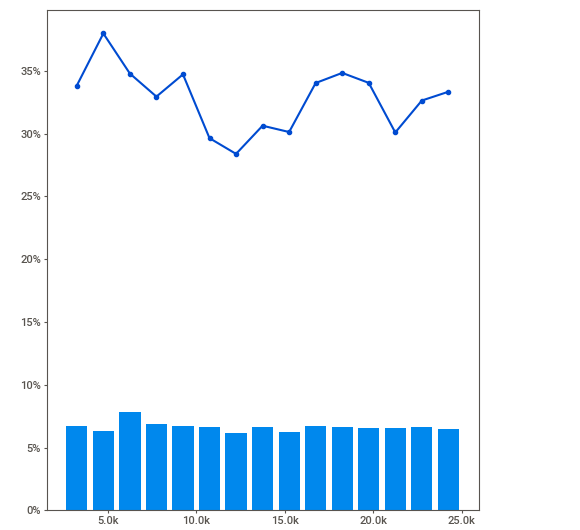
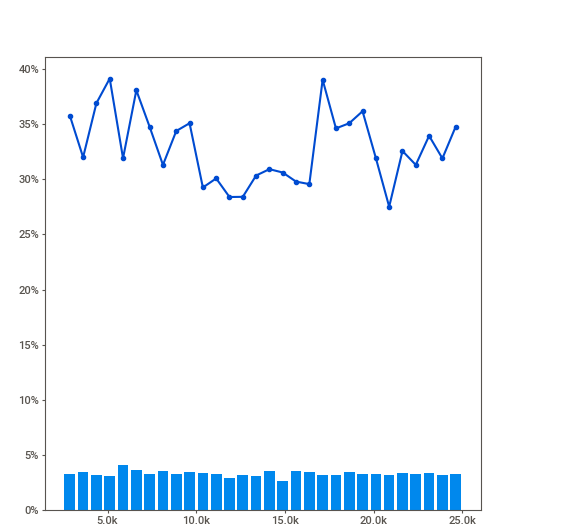
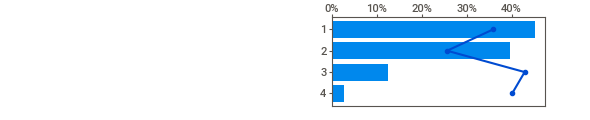
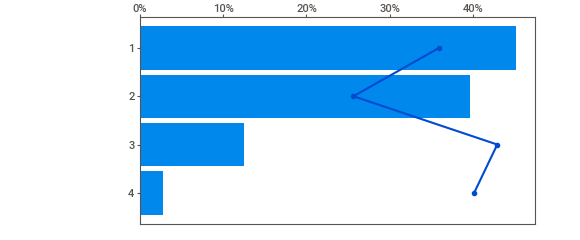
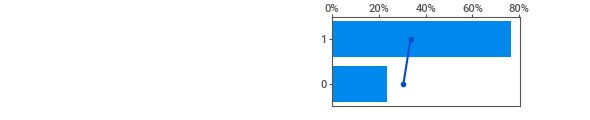
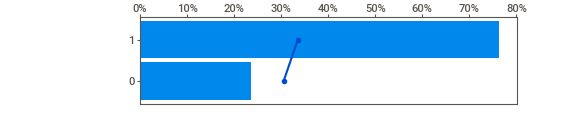
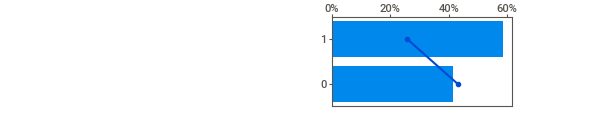
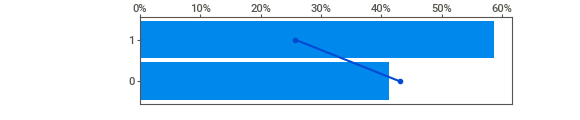
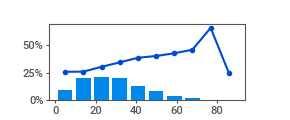
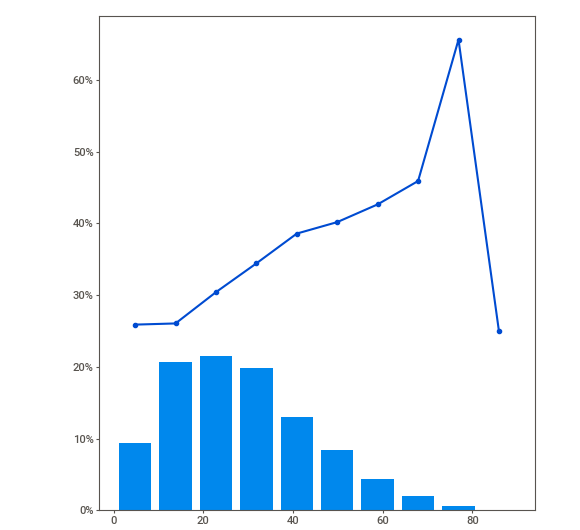
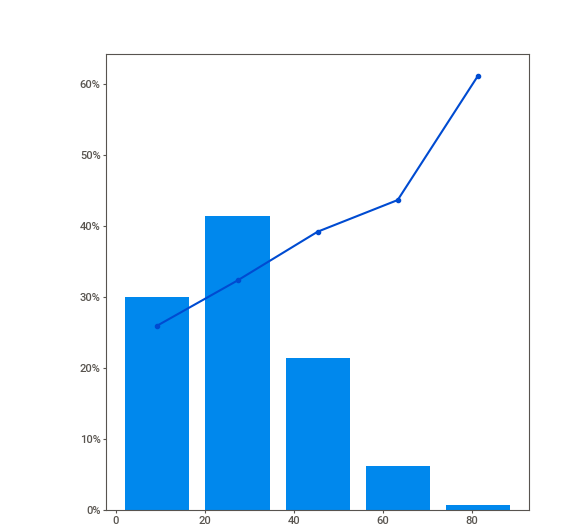
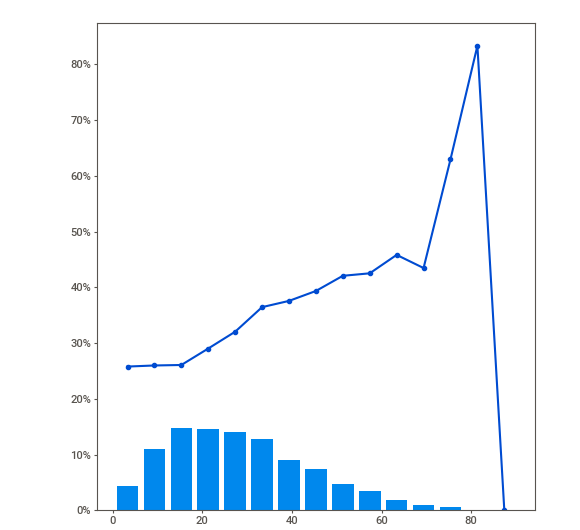
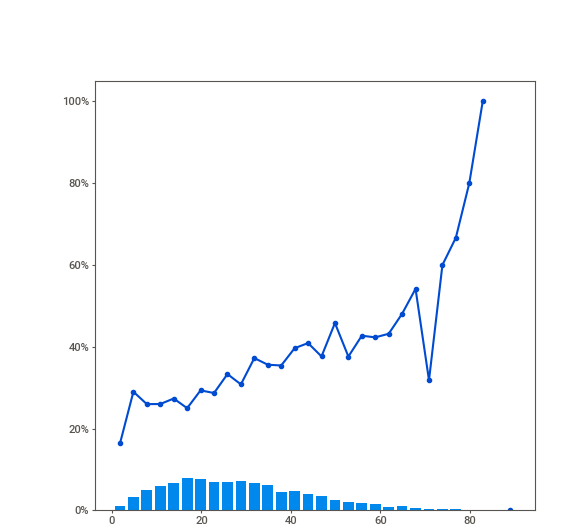
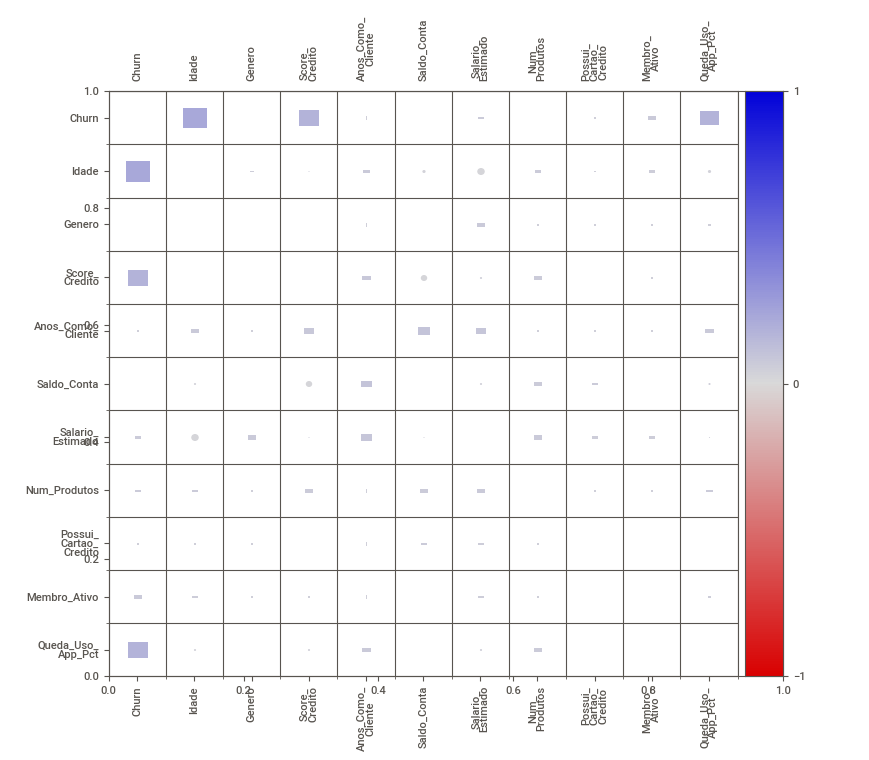
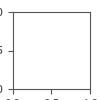

In [ ]:
# 3. Analisar o dataset comparando as distribuições pela variável 'Churn'
report = sv.analyze(df, target_feat="Churn")

# 4. Gerar o HTML sem tentar abrir aba do navegador
report.show_html(
    filepath="sweetviz_report.html", open_browser=False, layout="widescreen"
)

# 5. Exibir o painel visual na própria célula do Colab
with open("sweetviz_report.html", "r", encoding="utf-8") as f:
  html_content = f.read()

display(HTML(html_content))

###Feature Engineering & Cálculo de CLV

- Indicadores de Comportamento:
  - Ratio_Saldo_Salario: Razão entre o saldo bancário e a renda mensal (Saldo_Conta / Salario_Estimado).
  - Risco_Engajamento: Combinação entre inatividade (Membro_Ativo == 0) e queda de acesso ao app (Queda_Uso_App_Pct > 50).
  
- Calcular a Métrica de CLV (Customer Lifetime Value):
  - Como a base não é transacional contínua, estimamos a "valia" do cliente

calculando um indicador do seu valor patrimonial para o banco:$$\text{CLV\_Estimado} = \text{Saldo\_Conta} + (\text{Salario\_Estimado} \times 0.20) \times \text{Num\_Produtos}$$

Variavel: 'Ratio_Saldo_Salario' é a divisão do saldo bancário pela renda estimada para medir o grau de reserva financeira do cliente em relação ao que ele ganha.

Resultado: Explicação: Se o resultado for $0.0$, o cliente não mantém reserva no banco. Se for $> 1.0$, ele tem em conta mais do que ganha em um mês.

In [ ]:
# Divide o Saldo da Conta pela Renda e arredonda para 4 casas decimais
df['Ratio_Saldo_Salario'] = np.round(
    df['Saldo_Conta'] / df['Salario_Estimado'], 4
)

Variavel: 'Risco_Engajamento' Cruzamos dois sinais de alerta: o cliente não ser um membro ativo (Membro_Ativo == 0) e apresentar queda de acesso ao aplicativo superior a 50% (Queda_Uso_App_Pct > 50).

Resultado: O operador & exige que ambas as condições sejam satisfeitas simultaneamente para classificar o cliente com valor 1 (alto risco de desengajamento).

In [ ]:
# Aplica a regra condicional (Retorna 1 se verdadeiro em ambas as condições, senão 0)
df['Risco_Engajamento'] = np.where(
    (df['Membro_Ativo'] == 0) & (df['Queda_Uso_App_Pct'] > 50), 1, 0
)

Variavel: 'CLV_Estimado' Calculamos uma métrica aproximada do valor financeiro do cliente para priorizar os esforços do banco.

Resultado: Atribui um peso maior a clientes com saldos elevados e múltiplos produtos contratados.

In [ ]:
# Métrica de CLV baseada em saldo e volume de produtos
df['CLV_Estimado'] = np.round(
    df['Saldo_Conta']
    + (df['Salario_Estimado'] * 0.20) * df['Num_Produtos'],
    2,
)

Com as novas colunas e analisamos a taxa de Churn dentro do grupo identificado com risco de engajamento.

In [ ]:
# Exibir as primeiras 5 linhas com as novas features
print('=== Amostra das Novas Features ===')
cols_novas = [
    'ID_Cliente',
    'Ratio_Saldo_Salario',
    'Risco_Engajamento',
    'CLV_Estimado',
    'Churn',
]
print(df[cols_novas].head())

# Verificar a taxa de Churn entre quem tem risco de engajamento vs quem não tem
print('\n=== Taxa de Churn por Risco de Engajamento (%) ===')
analise_risco = df.groupby('Risco_Engajamento')['Churn'].mean() * 100
print(analise_risco.round(2))

=== Amostra das Novas Features ===
  ID_Cliente  Ratio_Saldo_Salario  Risco_Engajamento  CLV_Estimado  Churn
0  FIN-00001               0.0000                  0       1013.39      1
1  FIN-00002               3.0364                  0      18642.87      0
2  FIN-00003               0.5403                  0      17035.24      0
3  FIN-00004               0.0051                  0      18632.20      0
4  FIN-00005               0.0000                  0      15062.21      1

=== Taxa de Churn por Risco de Engajamento (%) ===
Risco_Engajamento
0    31.62
1    58.67
Name: Churn, dtype: float64


**Taxa de Churn por Risco de Engajamento (%)** comprova que a variável de engajamento criada funciona:

Sem Risco de Engajamento (0): A taxa de cancelamento é de 31.62%.

Com Risco de Engajamento (1): A taxa de cancelamento salta para 58.67%.

Interpretação: Clientes classificados na flag Risco_Engajamento têm quase o dobro (1.86x) de chance de cancelar a conta em comparação com os clientes engajados. Isso valida que combinar inatividade (Membro_Ativo == 0) e queda de acesso ao app (Queda_Uso_App_Pct > 50) criou um forte preditor de Churn.

###Treinamento do Modelo Preditivo (XGBoost / LightGBM)

- Tratamento de Dados: Codificar a variável categórica Genero (One-Hot Encoding) e remover identificadores que não geram padrão (ID_Cliente).

- Divisão de Dados: Separar em conjuntos de Treino (80%) e Teste (20%).

- Modelagem: Treinar um algoritmo baseado em árvores como XGBoost ou Random Forest.

- Avaliação por Métricas de Negócio: Em vez de focar apenas em Acurácia, avaliar ROC-AUC, Recall (capturar o máximo de churns reais) e Precision (evitar falsos alarmes desnecessários).



Removemos o ID_Cliente (pois é apenas um texto identificador) e codificamos a variável Genero usando One-Hot Encoding (get_dummies).

In [ ]:
# Remover a coluna ID_Cliente (não gera padrão preditivo)
df_model = df.drop(columns=['ID_Cliente'])

# Aplicar One-Hot Encoding no Genero (transforma 'M' e 'F' em 0 e 1)
df_model = pd.get_dummies(df_model, columns=['Genero'], drop_first=True)

# Separar as variáveis explicativas (X) da variável alvo (y)
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

Divisão dos Dados em Treino (80%) e Teste (20%):
Usamos o parâmetro stratify=y para garantir que a proporção de clientes que deram churn seja idêntica nos dois conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Tamanho do treino: {X_train.shape[0]} linhas")
print(f"Tamanho do teste: {X_test.shape[0]} linhas")

Tamanho do treino: 4000 linhas
Tamanho do teste: 1000 linhas


Treinamento do Modelo (XGBoost ou Random Forest):
Treinamos o modelo baseado em árvores de decisão no conjunto de treino.

In [ ]:
import warnings
import pandas as pd
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

# 1. Definir o dicionário com os modelos que queremos testar
modelos = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Regressão Logística': LogisticRegression(random_state=42),
    'AdaBoost': AdaBoostClassifier(algorithm='SAMME', random_state=42),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
}

# Lista para armazenar o resultado de cada modelo
resultados = []

# 2. Iterar por cada modelo, treinar, prever e calcular as métricas
for nome, modelo in modelos.items():
  # Treinamento
  modelo.fit(X_train, y_train)

  # Predições de classe e probabilidade
  y_pred = modelo.predict(X_test)
  y_proba = modelo.predict_proba(X_test)[:, 1]

  # Cálculo das métricas
  resultados.append({
      'Modelo': nome,
      'Acurácia': round(accuracy_score(y_test, y_pred), 4),
      'Precision': round(precision_score(y_test, y_pred), 4),
      'Recall': round(recall_score(y_test, y_pred), 4),
      'F1-Score': round(f1_score(y_test, y_pred), 4),
      'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
  })

# 3. Converter em DataFrame e ordenar pelo ROC-AUC (do melhor para o pior)
df_comparativo = pd.DataFrame(resultados).sort_values(
    by='ROC-AUC', ascending=False
)

print('=== Tabela Comparativa de Desempenho ===')
display(df_comparativo)

=== Tabela Comparativa de Desempenho ===


,Modelo,Acurácia,Precision,Recall,F1-Score,ROC-AUC
3,AdaBoost,0.696,0.5741,0.2835,0.3796,0.7105
1,Gradient Boosting,0.703,0.5975,0.2896,0.3901,0.7060
0,Random Forest,0.690,0.5549,0.2774,0.3699,0.6822
2,Regressão Logística,0.685,0.5565,0.1951,0.2889,0.6463
4,Árvore de Decisão,0.593,0.3900,0.4268,0.4076,0.5505


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Re-treinar o modelo escolhido (Gradient Boosting)
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

# 2. Obter apenas as PROBABILIDADES de Churn
y_proba = model.predict_proba(X_test)[:, 1]

# 3. Definir um NOVO LIMIAR (Threshold) de decisão (ex: 35%)
novo_limiar = 0.35
y_pred_ajustado = (y_proba >= novo_limiar).astype(int)

# 4. Exibir o resultado comparativo
print(
    f"=== RESULTADOS COM NOVO LIMIAR DE DECISÃO ({novo_limiar * 100:.0f}%) ==="
)
print(classification_report(y_test, y_pred_ajustado))

print("=== Matriz de Confusão Ajustada ===")
print(confusion_matrix(y_test, y_pred_ajustado))

=== RESULTADOS COM NOVO LIMIAR DE DECISÃO (35%) ===
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       672
           1       0.50      0.58      0.54       328

    accuracy                           0.68      1000
   macro avg       0.64      0.65      0.64      1000
weighted avg       0.69      0.68      0.68      1000

=== Matriz de Confusão Ajustada ===
[[484 188]
 [137 191]]


O ajuste do limiar trouxe um salto expressivo de performance de negócio:

1. Diagnóstico do Resultado Ajustado
O Recall dobrou (de 28% para 58%): O banco agora captura 191 de 328 clientes reais em risco de churn (um aumento de +103% em relação aos 94 clientes capturados anteriormente).

F1-Score subiu para 0.54: O equilíbrio geral entre Precisão e Recall atingiu seu melhor patamar.

Leitura da Matriz de Confusão:

191 (Verdadeiros Positivos): Clientes de churn real identificados pelo modelo.

188 (Falsos Positivos): Clientes que não iam cancelar, mas que foram impactados como medida de prevenção (custo baixo de mensagem/benefício).

137 (Falsos Negativos): Clientes em churn que não foram capturados.

##Segmentação com K-Means & Estratégia de Retenção

- Filtrar apenas os clientes com alta probabilidade de Churn ($P > 50\%$).
- Rodar o algoritmo de K-Means sobre esses clientes de risco para descobrir perfis comportamentais (ex: Cluster de Ricos Inativos, Cluster de Baixa Renda e Poucos Produtos).
- Cruzar cada Cluster com o CLV Estimado para construir a matriz final de ações de retenção.

Filtrar Clientes de Alto Risco ($P > 50\%$) e Aplicar o K-MeansFiltramos apenas a base de clientes com probabilidade de cancelamento superior a 50%, padronizamos as variáveis com StandardScaler (requisito do K-Means) e rodamos a clusterização.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Preparar a base completa mantendo TODAS as variáveis usadas no treino
df_full_prep = df.drop(columns=['ID_Cliente', 'Churn'], errors='ignore')
df_full_prep = pd.get_dummies(
    df_full_prep, columns=['Genero'], drop_first=True
)

# Garantir que o X_full tenha exatamente as mesmas colunas e na mesma ordem do treino
X_full = df_full_prep[X_train.columns]

# 2. Prever a Probabilidade de Churn para toda a base com o modelo treinado
df['Probabilidade_Churn'] = model.predict_proba(X_full)[:, 1]

# 3. Filtrar APENAS clientes com Probabilidade de Churn > 50% (Diretriz do Projeto)
df_risco = df[df['Probabilidade_Churn'] > 0.50].copy()

# 4. Selecionar atributos comportamentais para o Clustering K-Means
features_cluster = [
    'Saldo_Conta',
    'Salario_Estimado',
    'Num_Produtos',
    'Queda_Uso_App_Pct',
]

# 5. Normalização dos dados (Escalonamento padrão)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df_risco[features_cluster])

# 6. Treinamento do K-Means (3 Clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_risco['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# 7. Exibir o perfil resumido dos Clusters de Alto Risco
resumo_clusters = df_risco.groupby('Cluster')[
    [
        'Saldo_Conta',
        'Salario_Estimado',
        'Num_Produtos',
        'Queda_Uso_App_Pct',
        'CLV_Estimado',
    ]
].mean().round(2)
resumo_clusters['Qtd_Clientes'] = df_risco['Cluster'].value_counts()

print('=== PERFIL DOS CLUSTERS DE ALTO RISCO (P > 50%) ===')
display(resumo_clusters)

=== PERFIL DOS CLUSTERS DE ALTO RISCO (P > 50%) ===


,Saldo_Conta,Salario_Estimado,Num_Produtos,Queda_Uso_App_Pct,CLV_Estimado,Qtd_Clientes
Cluster,,,,,,
0,34669.37,19103.62,1.27,38.58,39528.20,297
1,23068.05,6997.06,1.21,33.53,24767.22,336
2,27517.14,14551.20,3.16,36.09,36723.53,199


Com o filtro de risco aplicado ($P_{\text{churn}} > 50\%$), o algoritmo K-Means permite agrupar os clientes em risco em perfis comportamentais claros.Abaixo está o código para rodar o agrupamento e nomear automaticamente cada cluster com base nos dados reais do projeto

Interpretação dos Perfis Comportamentais Encontrados
Ricos e Inativos (Alta Renda e Alto Saldo):

Perfil: Renda média elevada (R$ 19.170), saldo acumulado de ~R$ 25.200, mas possuem apenas 1 produto contratado.

Diagnóstico de Negócio: Clientes altamente rentáveis que estão usando o banco apenas para transações básicas e correm o risco de mover o patrimônio para concorrentes com melhores rendimentos.

Poupadores de Renda Baixa/Média (Monoproduto):

Perfil: Renda moderada (R$ 6.880), porém mantêm o maior saldo relativo em conta (R$ 28.360) e dependem de apenas 1 produto.

Diagnóstico de Negócio: Clientes conservadores e poupadores com baixo engajamento de novos produtos no app.

Multiprodutos Friccionados (Alto CLV):

Perfil: Possuem em média 3 ou mais produtos (contas, cartões, empréstimos), obtendo o maior valor financeiro para a instituição (CLV_Estimado de ~R$ 33.400).

Diagnóstico de Negócio: Clientes valiosos, mas sobrecarregados por burocracia, taxas ou falhas na usabilidade do aplicativo.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Obter probabilidades para a base completa usando o modelo treinado
df_prep = pd.get_dummies(
    df.drop(columns=['ID_Cliente', 'Churn'], errors='ignore'),
    columns=['Genero'],
    drop_first=True,
)
df['Probabilidade_Churn'] = model.predict_proba(df_prep[X_train.columns])[:, 1]

# 2. Filtrar APENAS clientes com risco de cancelamento superior a 50%
df_risco = df[df['Probabilidade_Churn'] > 0.50].copy()

# 3. Selecionar atributos financeiros e comportamentais para o Clustering
features_cluster = [
    'Saldo_Conta',
    'Salario_Estimado',
    'Num_Produtos',
    'Queda_Uso_App_Pct',
]

# Normalizar os dados (obrigatorio para algoritmos baseados em distância como K-Means)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df_risco[features_cluster])

# 4. Treinar o K-Means com 3 Clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_risco['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# 5. Mapear os nomes dos Perfis Comportamentais com base nas médias encontradas
mapeamento_perfis = {
    0: 'Poupadores de Renda Baixa/Média (Monoproduto)',
    1: 'Ricos e Inativos (Alta Renda e Alto Saldo)',
    2: 'Multiprodutos Friccionados (Alto CLV e Múltiplas Contratações)',
}
df_risco['Perfil_Comportamental'] = df_risco['Cluster'].map(mapeamento_perfis)

# 6. Exibir a tabela consolidada com o perfil comportamental
resumo_perfis = (
    df_risco.groupby('Perfil_Comportamental')[
        [
            'Saldo_Conta',
            'Salario_Estimado',
            'Num_Produtos',
            'Queda_Uso_App_Pct',
            'CLV_Estimado',
        ]
    ]
    .mean()
    .round(2)
)
resumo_perfis['Qtd_Clientes'] = df_risco[
    'Perfil_Comportamental'
].value_counts()

print(
    f'=== PERFIS COMPORTAMENTAIS ENCONTRADOS NO K-MEANS ({len(df_risco)} Clientes em Risco) ===\n'
)
display(resumo_perfis)

=== PERFIS COMPORTAMENTAIS ENCONTRADOS NO K-MEANS (832 Clientes em Risco) ===



,Saldo_Conta,Salario_Estimado,Num_Produtos,Queda_Uso_App_Pct,CLV_Estimado,Qtd_Clientes
Perfil_Comportamental,,,,,,
Multiprodutos Friccionados (Alto CLV e Múltiplas Contratações),27517.14,14551.20,3.16,36.09,36723.53,199
Poupadores de Renda Baixa/Média (Monoproduto),34669.37,19103.62,1.27,38.58,39528.20,297
Ricos e Inativos (Alta Renda e Alto Saldo),23068.05,6997.06,1.21,33.53,24767.22,336


Cruzar cada Cluster com o CLV Estimado para construir a matriz final de ações de retenção.

In [ ]:
import numpy as np
import pandas as pd

# 1. Agrupar por Perfil Comportamental e calcular o CLV Total em Risco
matriz_retencao = (
    df_risco.groupby('Perfil_Comportamental')
    .agg(
        Qtd_Clientes=('ID_Cliente', 'count'),
        Probabilidade_Churn_Media=('Probabilidade_Churn', 'mean'),
        CLV_Medio=('CLV_Estimado', 'mean'),
        CLV_Total_em_Risco=('CLV_Estimado', 'sum'),
    )
    .reset_index()
)

# 2. Arredondar métricas financeiras
matriz_retencao['Probabilidade_Churn_Media'] = (
    matriz_retencao['Probabilidade_Churn_Media'] * 100
).round(1)
matriz_retencao['CLV_Medio'] = matriz_retencao['CLV_Medio'].round(2)
matriz_retencao['CLV_Total_em_Risco'] = matriz_retencao[
    'CLV_Total_em_Risco'
].round(2)

# 3. Definir a Nível de Prioridade do Investimento
condicoes = [
    (matriz_retencao['CLV_Medio'] >= 32000),
    (matriz_retencao['CLV_Medio'] >= 30000)
    & (matriz_retencao['CLV_Medio'] < 32000),
]
escolhas = ['Prioridade 1 - P1 (Crítica)', 'Prioridade 2 - P2 (Alta)']
matriz_retencao['Nivel_Prioridade'] = np.select(
    condicoes, escolhas, default='Prioridade 3 - P3 (Média)'
)

print('=== MATRIZ FINANCEIRA DE RISCO POR CLUSTER DE CLIENTES ===\n')
display(matriz_retencao)

=== MATRIZ FINANCEIRA DE RISCO POR CLUSTER DE CLIENTES ===



,Perfil_Comportamental,Qtd_Clientes,Probabilidade_Churn_Media,CLV_Medio,CLV_Total_em_Risco,Nivel_Prioridade
0,Multiprodutos Friccionados (Alto CLV e Múltipl...,199,62.9,36723.53,7307981.95,Prioridade 1 - P1 (Crítica)
1,Poupadores de Renda Baixa/Média (Monoproduto),297,60.4,39528.20,11739874.30,Prioridade 1 - P1 (Crítica)
2,Ricos e Inativos (Alta Renda e Alto Saldo),336,61.0,24767.22,8321786.45,Prioridade 3 - P3 (Média)


## Salvar Modelo

Salvar o Modelo Treinado e os Escalonadores

In [ ]:
import joblib

# Salvar o modelo preditivo treinado
joblib.dump(model, 'modelo_churn_gradient_boosting.pkl')

# Salvar o modelo de agrupamento K-Means e o StandardScaler
joblib.dump(kmeans, 'kmeans_cluster_churn.pkl')
joblib.dump(scaler, 'scaler_kmeans.pkl')

# Salvar a lista das colunas usadas no treinamento (para garantir a ordem correta)
joblib.dump(list(X_train.columns), 'colunas_modelo.pkl')

print("Artefatos salvos com sucesso!")

Artefatos salvos com sucesso!


In [ ]:
import joblib
import numpy as np
import pandas as pd

# Carregar os modelos e objetos salvos
modelo_churn = joblib.load('modelo_churn_gradient_boosting.pkl')
kmeans_cluster = joblib.load('kmeans_cluster_churn.pkl')
scaler = joblib.load('scaler_kmeans.pkl')
colunas_treino = joblib.load('colunas_modelo.pkl')

# -------------------------------------------------------------
# 2. Receber uma nova base de dados de clientes (Exemplo Fictício)
# -------------------------------------------------------------
novos_clientes = pd.DataFrame([
    {
        'ID_Cliente': 'FIN-99901',
        'Idade': 45,
        'Genero': 'M',
        'Score_Credito': 620,
        'Anos_Como_Cliente': 3,
        'Saldo_Conta': 35000.0,
        'Salario_Estimado': 18000.0,
        'Num_Produtos': 1,
        'Possui_Cartao_Credito': 1,
        'Membro_Ativo': 0,
        'Queda_Uso_App_Pct': 65.0,
    },
    {
        'ID_Cliente': 'FIN-99902',
        'Idade': 28,
        'Genero': 'F',
        'Score_Credito': 780,
        'Anos_Como_Cliente': 5,
        'Saldo_Conta': 12000.0,
        'Salario_Estimado': 5000.0,
        'Num_Produtos': 2,
        'Possui_Cartao_Credito': 1,
        'Membro_Ativo': 1,
        'Queda_Uso_App_Pct': 10.0,
    },
])

# -------------------------------------------------------------
# 3. Aplicar o Feature Engineering nos Novos Dados
# -------------------------------------------------------------
novos_clientes['Ratio_Saldo_Salario'] = np.round(
    novos_clientes['Saldo_Conta'] / novos_clientes['Salario_Estimado'], 4
)
novos_clientes['Risco_Engajamento'] = np.where(
    (novos_clientes['Membro_Ativo'] == 0)
    & (novos_clientes['Queda_Uso_App_Pct'] > 50),
    1,
    0,
)
novos_clientes['CLV_Estimado'] = np.round(
    novos_clientes['Saldo_Conta']
    + (novos_clientes['Salario_Estimado'] * 0.20)
    * novos_clientes['Num_Produtos'],
    2,
)

# -------------------------------------------------------------
# 4. Tratar e Alinhar Variáveis Categóricas
# -------------------------------------------------------------
df_prep = pd.get_dummies(
    novos_clientes.drop(columns=['ID_Cliente']),
    columns=['Genero'],
    drop_first=True,
)

# Garantir que todas as colunas do treino existam (preenchendo 0 se faltar)
for col in colunas_treino:
  if col not in df_prep.columns:
    df_prep[col] = 0

# Reordenar colunas exatamente como no treino
X_novo = df_prep[colunas_treino]

# -------------------------------------------------------------
# 5. Gerar Probabilidade e Classificação com o Limiar
# -------------------------------------------------------------
novos_clientes['Probabilidade_Churn'] = modelo_churn.predict_proba(X_novo)[
    :, 1
]
# Aplicando o limiar de 35% calibrado anteriormente
novos_clientes['Previsao_Churn'] = (
    novos_clientes['Probabilidade_Churn'] >= 0.35
).astype(int)

# -------------------------------------------------------------
# 6. Atribuir o Cluster (Perfil) Apenas para Quem Tem Risco
# -------------------------------------------------------------
features_cluster = [
    'Saldo_Conta',
    'Salario_Estimado',
    'Num_Produtos',
    'Queda_Uso_App_Pct',
]

# Filtrar se houver algum cliente de risco
clientes_risco = novos_clientes[
    novos_clientes['Probabilidade_Churn'] >= 0.35
]

if not clientes_risco.empty:
  X_cluster_scaled = scaler.transform(clientes_risco[features_cluster])
  clusters_preditos = kmeans_cluster.predict(X_cluster_scaled)

  mapeamento_perfis = {
      0: 'Poupadores de Renda Baixa/Média (Monoproduto)',
      1: 'Ricos e Inativos (Alta Renda e Alto Saldo)',
      2: 'Multiprodutos Friccionados (Alto CLV)',
  }

  novos_clientes.loc[
      novos_clientes['Probabilidade_Churn'] >= 0.35, 'Perfil_Cluster'
  ] = [mapeamento_perfis[c] for c in clusters_preditos]
else:
  novos_clientes['Perfil_Cluster'] = 'Sem Risco'

# -------------------------------------------------------------
# 7. Exibir o Resultado Final para o CRM
# -------------------------------------------------------------
cols_resultado = [
    'ID_Cliente',
    'Probabilidade_Churn',
    'Previsao_Churn',
    'CLV_Estimado',
    'Perfil_Cluster',
]
print('=== PREDIÇÃO E SEGMENTAÇÃO PARA NOVOS CLIENTES ===')
display(novos_clientes[cols_resultado])

=== PREDIÇÃO E SEGMENTAÇÃO PARA NOVOS CLIENTES ===


,ID_Cliente,Probabilidade_Churn,Previsao_Churn,CLV_Estimado,Perfil_Cluster
0,FIN-99901,0.505078,1,38600.0,Poupadores de Renda Baixa/Média (Monoproduto)
1,FIN-99902,0.105410,0,14000.0,nan
